In [2]:
from algorithm_evaluation import evaluate
import pandas as pd


In [ ]:

small_networks= ['asia', 'sachs'] #path: small-networks/
medium_networks = ['alarm', 'barley', 'child', 'insurance', 'mildew', 'water'] # path: medium-networks/

all_graphs_paths = [f'small-networks/{graph}.bif' for graph in small_networks] + \
                   [f'medium-networks/{graph}.bif' for graph in medium_networks]
df = pd.DataFrame()

path_prefix= 'algorithm_evaluation/example-graphs/bnlearn/'

CF_fractions = [0, 0.25, 0.5, 0.75, 1]
for CF_fraction in CF_fractions:
    print(f"Evaluating CF_fraction: {CF_fraction}")
    for graph_path in all_graphs_paths:
        print(f"Evaluating graph: {graph_path}")
        df = pd.concat([df, evaluate(
            path_prefix + graph_path,
            confounding_probs=[0.005, 0.015, 0.025, 0.035], # Akbari: [0.05, 0.15, 0.25, 0.35]
            n_simulations=10,
            seed=42,
            verbose=True,
            experiment_set_size=50,
            theta_config=  {
                'CF_fraction': 1,
                'W_size_mean': 2, # good perfm: W ~ N(1,0)
                'W_size_sd': 1,
                'Z_size_mean': 2,
                'Z_size_sd': 1,
                'intervention_outcome_distance_mean': 1,
                'intervention_outcome_distance_sd': 0
            },
            experiment_config={
                'CF_fraction': CF_fraction,
                'W_size_mean': 3,
                'W_size_sd': 5,
                'Z_size_mean': 5,
                'Z_size_sd': 5,
            }
        )], ignore_index=True)


Evaluating graph: small-networks/asia.bif
Graph: asia.bif, |V|=8, |A|=50
  p=0.015, sim 10/10: pruned 100.0%
  p=0.025, sim 10/10: pruned 100.0%
  p=0.035, sim 10/10: pruned 88.0%
Evaluating graph: small-networks/sachs.bif
Graph: sachs.bif, |V|=11, |A|=50
  p=0.005, sim 10/10: pruned 100.0%
  p=0.015, sim 10/10: pruned 100.0%
  p=0.025, sim 10/10: pruned 100.0%
  p=0.035, sim 10/10: pruned 100.0%
Evaluating graph: medium-networks/alarm.bif
Graph: alarm.bif, |V|=37, |A|=50
  p=0.015, sim 10/10: pruned 72.0%
  p=0.025, sim 10/10: pruned 60.0%
  p=0.035, sim 10/10: pruned 62.0%
Evaluating graph: medium-networks/barley.bif
Graph: barley.bif, |V|=48, |A|=50
  p=0.005, sim 10/10: pruned 58.0%
  p=0.015, sim 10/10: pruned 54.0%
  p=0.025, sim 10/10: pruned 44.0%
  p=0.035, sim 10/10: pruned 44.0%
Evaluating graph: medium-networks/child.bif
Graph: child.bif, |V|=20, |A|=50
  p=0.005, sim 10/10: pruned 100.0%
  p=0.015, sim 10/10: pruned 82.0%
  p=0.025, sim 10/10: pruned 62.0%
  p=0.035, sim 1

In [3]:
df = evaluate(
        'algorithm_evaluation/example-graphs/bnlearn/medium-networks/alarm.bif',
        confounding_probs=[0.005], # Akbari: [0.05, 0.15, 0.25, 0.35]
        n_simulations=10,
        seed=42,
        verbose=True,
        experiment_set_size=50,
        theta_config=  {
            'CF_fraction': 0.5,
            'W_size_mean': 1,
            'W_size_sd': 0,
            'Z_size_mean': 2,
            'Z_size_sd': 1,
            'intervention_outcome_distance_mean': 1,
            'intervention_outcome_distance_sd': 0
        },
        experiment_config={
            'CF_fraction': .5,
            'W_size_mean': 3,
            'W_size_sd': 5,
            'Z_size_mean': 5,
            'Z_size_sd': 5,
        })

Graph: alarm.bif, |V|=37, |A|=50


In [ ]:
# df.to_csv('algorithm_evaluation/results/14_03__16_33__moreCF.csv', index=False)


In [4]:
df

,graph,n_vars,p_conf,sim,n_confounders,query,query_is_cf,n_R_theta,n_R_theta_star,n_experiments,n_cf_experiments,fraction_cf,n_useless,n_useful,fraction_pruned,id_pruned,blocked_pruned
0,alarm.bif,37,0.005,1,8,"Y={'CATECHOL'}, X={'TPR'}",False,4,4,50,25,0.50,26,24,0.52,22,4
1,alarm.bif,37,0.005,3,6,"Y={'ARTCO2'}, X={'VENTMACH'}; Y={'PVSAT'}, X={...",True,2,2,50,28,0.56,23,27,0.46,20,3
2,alarm.bif,37,0.005,4,5,"Y={'LVEDVOLUME'}, X={'LVFAILURE', 'HYPOVOLEMIA...",True,0,0,50,26,0.52,50,0,1.00,24,26
3,alarm.bif,37,0.005,5,3,"Y={'VENTLUNG'}, X={'KINKEDTUBE', 'VENTMACH'}; ...",True,2,2,50,21,0.42,34,16,0.68,29,5
4,alarm.bif,37,0.005,7,4,"Y={'STROKEVOLUME'}, X={'LVFAILURE', 'HYPOVOLEM...",False,0,0,50,24,0.48,50,0,1.00,26,24
5,alarm.bif,37,0.005,8,4,"Y={'CVP'}, X={'LVFAILURE', 'LVEDVOLUME', 'HYPO...",True,4,4,50,21,0.42,27,23,0.54,26,1


[Text(0, 0, '0.00'),
 Text(1, 0, ''),
 Text(2, 0, ''),
 Text(3, 0, ''),
 Text(4, 0, ''),
 Text(5, 0, ''),
 Text(6, 0, ''),
 Text(7, 0, ''),
 Text(8, 0, ''),
 Text(9, 0, ''),
 Text(10, 0, '0.08'),
 Text(11, 0, ''),
 Text(12, 0, ''),
 Text(13, 0, ''),
 Text(14, 0, ''),
 Text(15, 0, ''),
 Text(16, 0, ''),
 Text(17, 0, ''),
 Text(18, 0, ''),
 Text(19, 0, ''),
 Text(20, 0, '0.15'),
 Text(21, 0, ''),
 Text(22, 0, ''),
 Text(23, 0, ''),
 Text(24, 0, ''),
 Text(25, 0, ''),
 Text(26, 0, ''),
 Text(27, 0, ''),
 Text(28, 0, ''),
 Text(29, 0, ''),
 Text(30, 0, '0.22'),
 Text(31, 0, ''),
 Text(32, 0, ''),
 Text(33, 0, ''),
 Text(34, 0, ''),
 Text(35, 0, ''),
 Text(36, 0, ''),
 Text(37, 0, ''),
 Text(38, 0, ''),
 Text(39, 0, ''),
 Text(40, 0, '0.30'),
 Text(41, 0, ''),
 Text(42, 0, ''),
 Text(43, 0, ''),
 Text(44, 0, ''),
 Text(45, 0, ''),
 Text(46, 0, ''),
 Text(47, 0, ''),
 Text(48, 0, ''),
 Text(49, 0, ''),
 Text(50, 0, '0.38'),
 Text(51, 0, ''),
 Text(52, 0, ''),
 Text(53, 0, ''),
 Text(54, 0, '

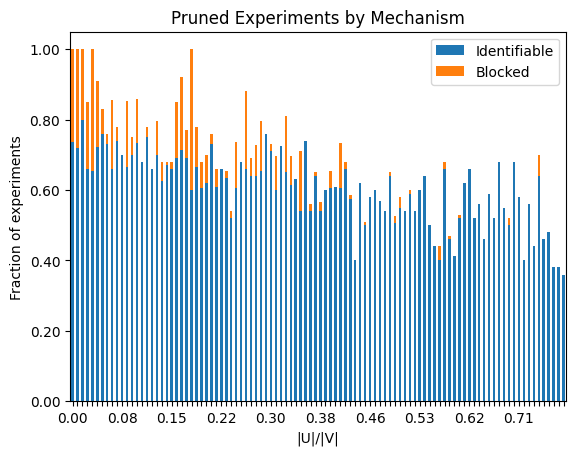

In [5]:
from matplotlib.ticker import FormatStrFormatter

p = pd.DataFrame()
p['fraction_id'] = df['id_pruned'] / df['n_experiments']
p['fraction_blocked'] = df['blocked_pruned'] / df['n_experiments']
p['fraction_confounders'] = df['n_confounders'] / df['n_vars']

p = p.groupby('fraction_confounders').mean()[['fraction_id', 'fraction_blocked']]
p.index = p.index.round(2)

ax = p.plot(kind='bar', stacked=True)
ax.set_xlabel('|U|/|V|')
ax.set_ylabel('Fraction of experiments')
ax.set_title('Pruned Experiments by Mechanism')
ax.legend(['Identifiable', 'Blocked'])

# format y-axis to 2 decimals
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# show only every 5th x-axis label
xlabels = [f"{v:.2f}" if i % 10 == 0 else "" for i, v in enumerate(p.index)]
ax.set_xticklabels(xlabels, rotation=0)




/tmp/ipykernel_120583/3402344151.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Confounding probability')


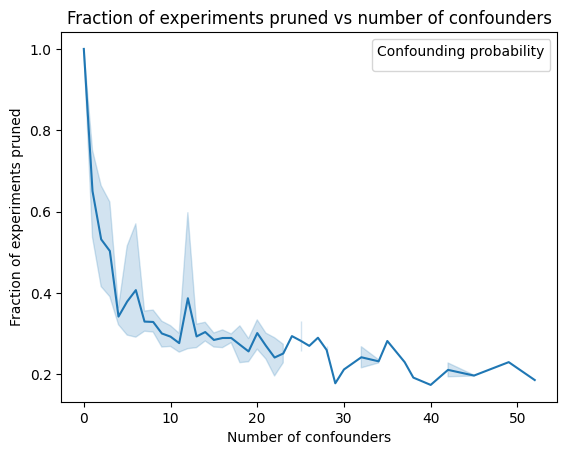

In [103]:
# plot fraction_pruned vs n_confounders as line chart
# for each value of n_confounders, compute the mean fraction_pruned across all simulations and plot it
import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(data=df, x='n_confounders', y='fraction_pruned')
plt.xlabel('Number of confounders')
plt.ylabel('Fraction of experiments pruned')
plt.title('Fraction of experiments pruned vs number of confounders')
plt.legend(title='Confounding probability')
plt.show()
